In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#c9ccd6',
    'text.color'       : '#c9ccd6',
    'xtick.color'      : '#8b8fa8',
    'ytick.color'      : '#8b8fa8',
    'grid.color'       : '#2a2d3a',
    'grid.alpha'       : 0.5,
})

ACCENT = ['#4e8ef7','#f76e6e','#56d98e','#f7c948',
          '#b48ef7','#f7914e','#4ec9f7','#f74e8e']
SAVE   = '/tmp/agro_eda/'

import os
os.makedirs(SAVE, exist_ok=True)

df = pd.read_csv(
    '/Volumes/weather/weather15/up15/agro_up_clean.csv',
    low_memory=False
)
df['date']  = pd.to_datetime(df['date'], errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print("=" * 60)
print("AG4P-6 | STEP 1 - Building City Profile Table")
print("=" * 60)

# One row per city — mean annual values of all key variables
city_profile = df.groupby(
    ['city_clean', 'latitude', 'longitude']
).agg(
    mean_temp       = ('temp_mean',      'mean'),
    mean_temp_max   = ('temp_max',       'mean'),
    mean_temp_min   = ('temp_min',       'mean'),
    mean_humidity   = ('humidity_mean',  'mean'),
    mean_dew        = ('dew_mean',       'mean'),
    total_precip    = ('precip_total',   'sum'),
    mean_precip     = ('precip_total',   'mean'),
    rain_days_pct   = ('rain_occurred',  'mean'),
    mean_cloud      = ('cloud_mean',     'mean'),
    mean_wind_100m  = ('wind_mean_100m', 'mean'),
    max_wind_100m   = ('wind_max_100m',  'max'),
    mean_pressure   = ('pressure_mean',  'mean'),
    row_count       = ('temp_mean',      'count'),
).reset_index()

city_profile['rain_days_pct'] = (
    city_profile['rain_days_pct'] * 100
).round(1)

print("  City profile built:", len(city_profile), "cities")
print("  Columns:", city_profile.columns.tolist())
print()
print("  Sample (sorted by latitude north to south):")
sample = city_profile.sort_values(
    'latitude', ascending=False
)[['city_clean','latitude','longitude',
   'mean_temp','mean_humidity','mean_wind_100m',
   'rain_days_pct']].head(10)
print(sample.to_string(index=False))

AG4P-6 | STEP 1 - Building City Profile Table
  City profile built: 50 cities
  Columns: ['city_clean', 'latitude', 'longitude', 'mean_temp', 'mean_temp_max', 'mean_temp_min', 'mean_humidity', 'mean_dew', 'total_precip', 'mean_precip', 'rain_days_pct', 'mean_cloud', 'mean_wind_100m', 'max_wind_100m', 'mean_pressure', 'row_count']

  Sample (sorted by latitude north to south):
   city_clean  latitude  longitude  mean_temp  mean_humidity  mean_wind_100m  rain_days_pct
Muzaffarnagar   29.4820    77.7000  23.373546      67.046107       14.830882           40.6
       Nagina   29.4430    78.4330  23.043611      68.412708       13.285758           39.0
      Kairana   29.3953    77.2053  23.544989      65.804811       15.594954           38.7
       Meerut   28.9800    77.7100  23.715237      65.659647       15.384608           38.0
       Amroha   28.9044    78.4675  23.681155      67.042559       15.608563           39.5
    Moradabad   28.8389    78.7769  23.753950      67.281172       15

Sparse City Check

In [0]:
print("=" * 60)
print("AG4P-6 | STEP 2 - Data Coverage per City")
print("=" * 60)

avg_rows = city_profile['row_count'].mean()
city_profile['sparse_flag'] = city_profile['row_count'].apply(
    lambda x: 'SPARSE' if x < avg_rows * 0.7 else 'OK'
)

print("  Average rows per city:", round(avg_rows))
print()
print("  All cities — row count and sparse flag:")
print("  City                       Rows    Flag")
print("-" * 45)
for _, row in city_profile.sort_values(
    'row_count', ascending=False
).iterrows():
    print(" ", row['city_clean'][:25].ljust(25),
          str(int(row['row_count'])).rjust(6),
          " ", row['sparse_flag'])

sparse_cities = city_profile[
    city_profile['sparse_flag'] == 'SPARSE'
]['city_clean'].tolist()

print()
print("  Sparse cities (exclude from PS1 onset labelling):",
      sparse_cities if sparse_cities else "None")

AG4P-6 | STEP 2 - Data Coverage per City
  Average rows per city: 5164

  All cities — row count and sparse flag:
  City                       Rows    Flag
---------------------------------------------
  Achhnera                    5164   OK
  Lucknow                     5164   OK
  Hapur                       5164   OK
  Hathras                     5164   OK
  Jaunpur                     5164   OK
  Jhansi                      5164   OK
  Kairana                     5164   OK
  Kalpi                       5164   OK
  Kanpur                      5164   OK
  Laharpur                    5164   OK
  Lakhna                      5164   OK
  Lalganj                     5164   OK
  Mathura                     5164   OK
  Agra                        5164   OK
  Mau                         5164   OK
  Meerut                      5164   OK
  Mirzapur                    5164   OK
  Moradabad                   5164   OK
  Muhammadabad                5164   OK
  Muzaffarnagar               5164   O

Three India/UP Scatter Maps

AG4P-6 | STEP 3 - Spatial Scatter Maps


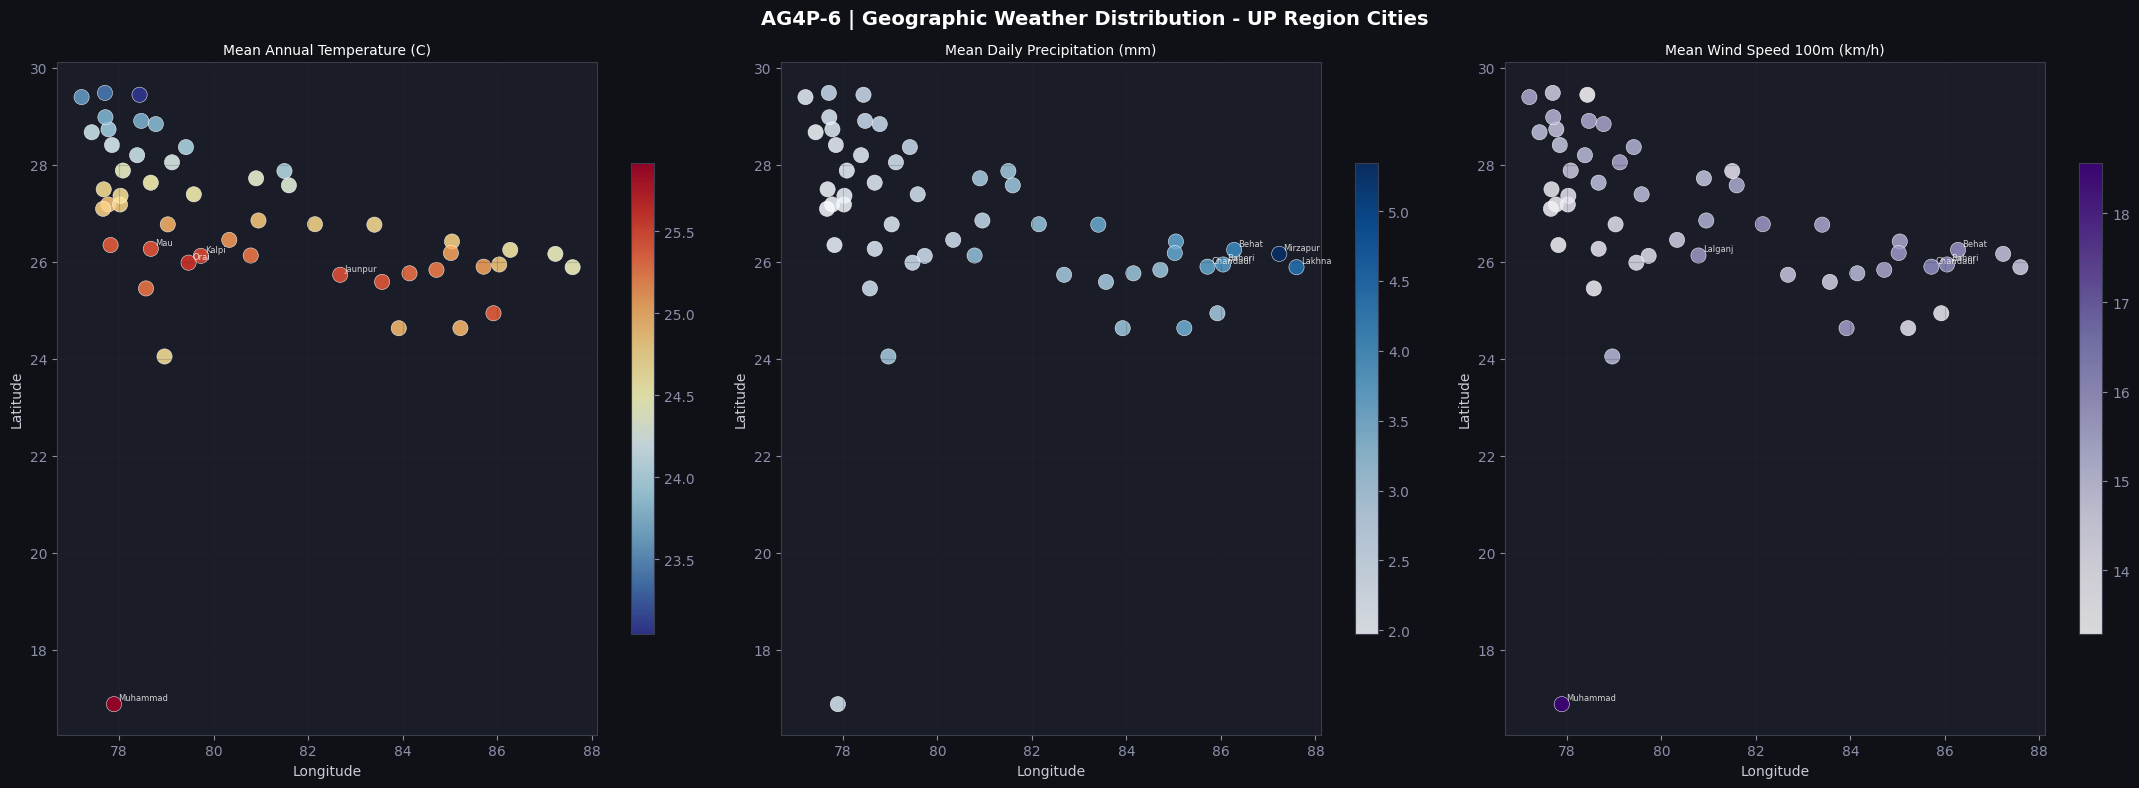

Saved: ag4p6_spatial_maps.png


In [0]:
print("=" * 60)
print("AG4P-6 | STEP 3 - Spatial Scatter Maps")
print("=" * 60)

map_targets = [
    ('mean_temp',      'Mean Annual Temperature (C)',    'RdYlBu_r'),
    ('mean_precip',    'Mean Daily Precipitation (mm)',  'Blues'),
    ('mean_wind_100m', 'Mean Wind Speed 100m (km/h)',    'Purples'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle(
    'AG4P-6 | Geographic Weather Distribution - UP Region Cities',
    fontsize=14, fontweight='bold', color='white'
)

for ax, (col, label, cmap) in zip(axes, map_targets):
    sc = ax.scatter(
        city_profile['longitude'],
        city_profile['latitude'],
        c     = city_profile[col],
        cmap  = cmap,
        s     = 120,
        alpha = 0.85,
        edgecolors = 'white',
        linewidths = 0.4
    )
    plt.colorbar(sc, ax=ax, shrink=0.7)

    # Label top 5 and bottom 5 cities for this metric
    top5 = city_profile.nlargest(5, col)
    for _, r in top5.iterrows():
        ax.annotate(
            r['city_clean'][:8],
            (r['longitude'], r['latitude']),
            fontsize=6, color='white', alpha=0.8,
            xytext=(3, 3), textcoords='offset points'
        )

    ax.set_title(label, fontsize=10, color='white')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p6_spatial_maps.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p6_spatial_maps.png")

West vs East UP Comparison

AG4P-6 | STEP 4 - West vs East UP Weather Profile
  Splitting UP at longitude: 79.44


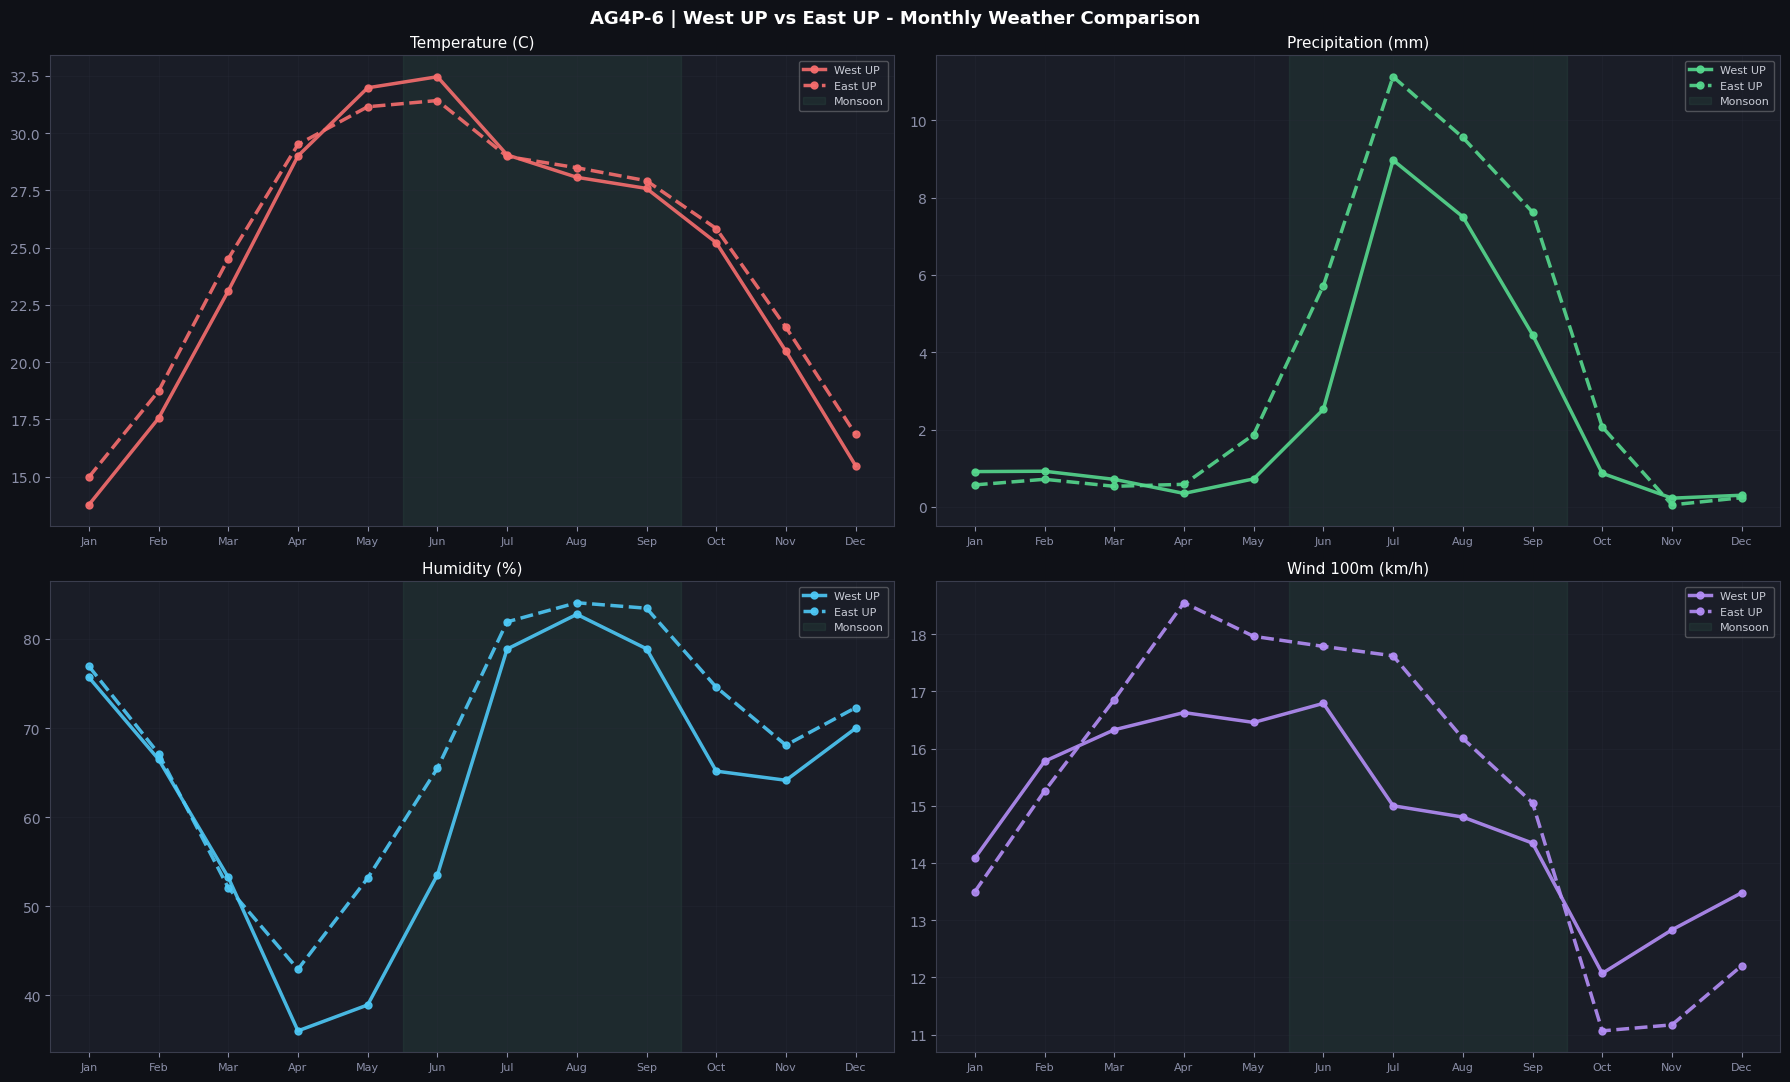

Saved: ag4p6_west_east_comparison.png

  West UP vs East UP — Annual Averages:
  Metric              West UP    East UP    Difference
-------------------------------------------------------
  Mean Rain (mm)           2.37       3.38         1.01
  Mean Humidity %         63.77      68.61         4.84
  Mean Wind km/h          14.87      15.25         0.38


In [0]:
print("=" * 60)
print("AG4P-6 | STEP 4 - West vs East UP Weather Profile")
print("=" * 60)

# UP spans roughly 77.5E to 84.5E longitude
# Split at midpoint ~81E
mid_lng = df['longitude'].median()
print("  Splitting UP at longitude:", round(mid_lng, 2))

df['region'] = df['longitude'].apply(
    lambda x: 'West UP' if x < mid_lng else 'East UP'
)

region_monthly = df.groupby(['region', 'month']).agg(
    temp    = ('temp_mean',      'mean'),
    rain    = ('precip_total',   'mean'),
    humidity= ('humidity_mean',  'mean'),
    wind    = ('wind_mean_100m', 'mean'),
).reset_index()

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle(
    'AG4P-6 | West UP vs East UP - Monthly Weather Comparison',
    fontsize=13, fontweight='bold', color='white'
)

pairs = [
    ('temp',     'Temperature (C)',    '#f76e6e'),
    ('rain',     'Precipitation (mm)', '#56d98e'),
    ('humidity', 'Humidity (%)',        '#4ec9f7'),
    ('wind',     'Wind 100m (km/h)',    '#b48ef7'),
]

for ax, (col, label, color) in zip(axes.flat, pairs):
    for region, style, alpha in [
        ('West UP', '-',  0.9),
        ('East UP', '--', 0.9)
    ]:
        sub = region_monthly[
            region_monthly['region'] == region
        ].sort_values('month')
        ax.plot(
            sub['month'], sub[col],
            color=color, lw=2.5,
            linestyle=style, alpha=alpha,
            marker='o', markersize=5,
            label=region
        )

    ax.axvspan(5.5, 9.5, alpha=0.07,
               color='#56d98e', label='Monsoon')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=8)
    ax.set_title(label, fontsize=11, color='white')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p6_west_east_comparison.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p6_west_east_comparison.png")

# Print key difference numbers
print()
print("  West UP vs East UP — Annual Averages:")
print("  Metric              West UP    East UP    Difference")
print("-" * 55)
for col, label in [
    ('temp_mean',     'Mean Temp (C)'),
    ('mean_precip',   'Mean Rain (mm)'),
    ('mean_humidity', 'Mean Humidity %'),
    ('mean_wind_100m','Mean Wind km/h'),
]:
    if col in city_profile.columns:
        west = city_profile[
            city_profile['longitude'] < mid_lng
        ][col].mean()
        east = city_profile[
            city_profile['longitude'] >= mid_lng
        ][col].mean()
        diff = east - west
        print(" ", label.ljust(20),
              str(round(west, 2)).rjust(8),
              str(round(east, 2)).rjust(10),
              str(round(diff, 2)).rjust(12))

Monsoon Arrival by Latitude

AG4P-6 | STEP 5 - Monsoon Arrival by Latitude


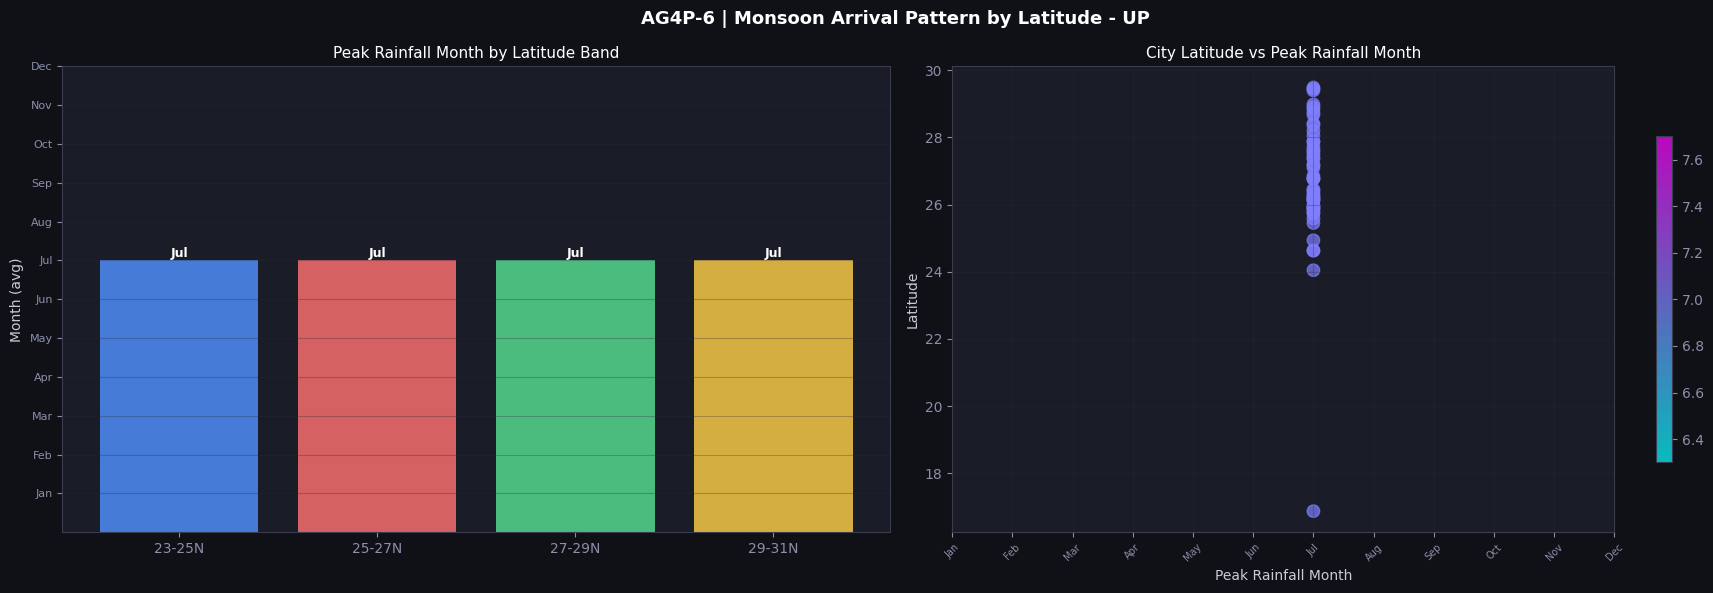

Saved: ag4p6_monsoon_by_latitude.png

  Peak rainfall month by latitude band:
  23-25N     → peak month: Jul
  25-27N     → peak month: Jul
  27-29N     → peak month: Jul
  29-31N     → peak month: Jul


In [0]:
print("=" * 60)
print("AG4P-6 | STEP 5 - Monsoon Arrival by Latitude")
print("=" * 60)

# Peak rainfall month per city
city_month_rain = df.groupby(
    ['city_clean', 'latitude', 'month']
)['precip_total'].mean().reset_index()

peak_rain = city_month_rain.loc[
    city_month_rain.groupby('city_clean')['precip_total'].idxmax()
][['city_clean', 'latitude', 'month']].dropna()

# Bin by latitude bands
peak_rain['lat_band'] = pd.cut(
    peak_rain['latitude'],
    bins   = [23, 25, 27, 29, 31, 33],
    labels = ['23-25N', '25-27N', '27-29N', '29-31N', '31-33N']
)

lat_band_peak = peak_rain.groupby(
    'lat_band', observed=True
)['month'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'AG4P-6 | Monsoon Arrival Pattern by Latitude - UP',
    fontsize=13, fontweight='bold', color='white'
)

# Bar chart — peak rain month by lat band
axes[0].bar(
    lat_band_peak['lat_band'].astype(str),
    lat_band_peak['month'],
    color=ACCENT[:5], alpha=0.85, edgecolor='none'
)
axes[0].set_title(
    'Peak Rainfall Month by Latitude Band',
    fontsize=11, color='white'
)
axes[0].set_ylabel('Month (avg)')
axes[0].set_yticks(range(1, 13))
axes[0].set_yticklabels(MONTHS, fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')
for i, (_, row) in enumerate(lat_band_peak.iterrows()):
    axes[0].text(
        i, row['month'] + 0.1,
        MONTHS[int(row['month']) - 1],
        ha='center', fontsize=9,
        color='white', fontweight='bold'
    )

# Scatter — latitude vs peak rain month per city
sc = axes[1].scatter(
    peak_rain['month'],
    peak_rain['latitude'],
    c     = peak_rain['month'],
    cmap  = 'cool',
    s     = 80,
    alpha = 0.7
)
axes[1].set_xlabel('Peak Rainfall Month')
axes[1].set_ylabel('Latitude')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONTHS, fontsize=7, rotation=45)
axes[1].set_title(
    'City Latitude vs Peak Rainfall Month',
    fontsize=11, color='white'
)
axes[1].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[1], shrink=0.7)

plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p6_monsoon_by_latitude.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p6_monsoon_by_latitude.png")

print()
print("  Peak rainfall month by latitude band:")
for _, row in lat_band_peak.iterrows():
    print(" ", str(row['lat_band']).ljust(10),
          "→ peak month:", MONTHS[int(row['month']) - 1])

PS3 Renewable Energy First-Pass Map

AG4P-6 | STEP 6 - PS3 Renewable Energy First-Pass
  Wind classification:
wind_class
Medium (13-18 km/h)    49
High (>18 km/h)         1

  Solar proxy classification:
solar_class
Medium (70-80)    36
High (>80)        11
Low (<70)          3


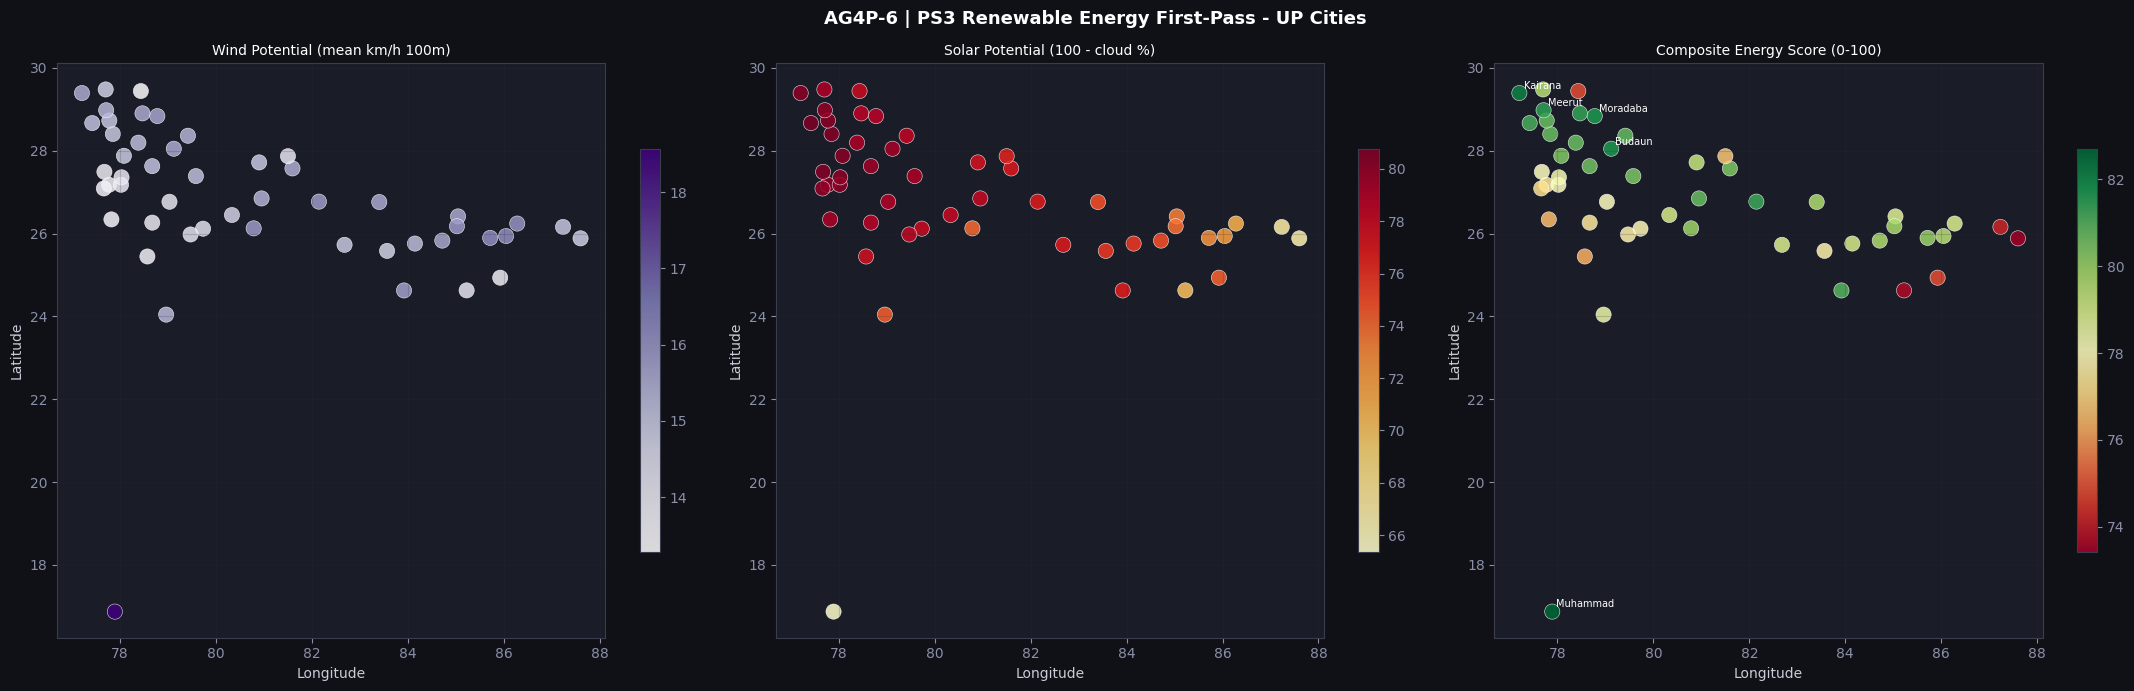

Saved: ag4p6_renewable_energy_map.png

  Top 5 cities by composite energy score:
  City                  Wind    Solar   Score
--------------------------------------------------
  Muhammadabad           18.6     65.4    82.69
  Kairana                15.6     80.3    82.16
  Budaun                 15.6     79.4     81.7
  Moradabad              15.7     78.7    81.68
  Meerut                 15.4     80.1    81.51


In [0]:
print("=" * 60)
print("AG4P-6 | STEP 6 - PS3 Renewable Energy First-Pass")
print("=" * 60)

# Wind potential classification
city_profile['wind_class'] = city_profile['mean_wind_100m'].apply(
    lambda x: 'High (>18 km/h)'    if x > 18 else
              'Medium (13-18 km/h)' if x > 13 else
              'Low (<13 km/h)'
)

# Solar proxy — inverse of cloud cover
city_profile['solar_score'] = 100 - city_profile['mean_cloud']
city_profile['solar_class'] = city_profile['solar_score'].apply(
    lambda x: 'High (>80)'    if x > 80 else
              'Medium (70-80)' if x > 70 else
              'Low (<70)'
)

# Composite energy score
city_profile['energy_score'] = (
    (city_profile['mean_wind_100m'] / city_profile['mean_wind_100m'].max() * 50) +
    (city_profile['solar_score']    / 100 * 50)
).round(2)

print("  Wind classification:")
print(city_profile['wind_class'].value_counts().to_string())
print()
print("  Solar proxy classification:")
print(city_profile['solar_class'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    'AG4P-6 | PS3 Renewable Energy First-Pass - UP Cities',
    fontsize=13, fontweight='bold', color='white'
)

# Wind potential map
sc1 = axes[0].scatter(
    city_profile['longitude'],
    city_profile['latitude'],
    c     = city_profile['mean_wind_100m'],
    cmap  = 'Purples',
    s     = 120, alpha = 0.85,
    edgecolors = 'white', linewidths = 0.4
)
plt.colorbar(sc1, ax=axes[0], shrink=0.7)
axes[0].set_title('Wind Potential (mean km/h 100m)',
                  fontsize=10, color='white')

# Solar potential map
sc2 = axes[1].scatter(
    city_profile['longitude'],
    city_profile['latitude'],
    c     = city_profile['solar_score'],
    cmap  = 'YlOrRd',
    s     = 120, alpha = 0.85,
    edgecolors = 'white', linewidths = 0.4
)
plt.colorbar(sc2, ax=axes[1], shrink=0.7)
axes[1].set_title('Solar Potential (100 - cloud %)',
                  fontsize=10, color='white')

# Composite energy score map
sc3 = axes[2].scatter(
    city_profile['longitude'],
    city_profile['latitude'],
    c     = city_profile['energy_score'],
    cmap  = 'RdYlGn',
    s     = 120, alpha = 0.85,
    edgecolors = 'white', linewidths = 0.4
)
plt.colorbar(sc3, ax=axes[2], shrink=0.7)
axes[2].set_title('Composite Energy Score (0-100)',
                  fontsize=10, color='white')

# Label top 5 energy cities
top5_energy = city_profile.nlargest(5, 'energy_score')
for _, r in top5_energy.iterrows():
    axes[2].annotate(
        r['city_clean'][:8],
        (r['longitude'], r['latitude']),
        fontsize=7, color='white',
        xytext=(3, 3), textcoords='offset points'
    )

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p6_renewable_energy_map.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p6_renewable_energy_map.png")

print()
print("  Top 5 cities by composite energy score:")
print("  City                  Wind    Solar   Score")
print("-" * 50)
for _, r in top5_energy.iterrows():
    print(" ", r['city_clean'].ljust(20),
          str(round(r['mean_wind_100m'], 1)).rjust(6),
          str(round(r['solar_score'], 1)).rjust(8),
          str(r['energy_score']).rjust(8))

 Anomalous City Check

In [0]:
print("=" * 60)
print("AG4P-6 | STEP 7 - Anomalous City Check")
print("=" * 60)

# Flag cities where any metric is more than 2 std from mean
flags = []
for col, label in [
    ('mean_temp',      'Temperature'),
    ('mean_precip',    'Precipitation'),
    ('mean_wind_100m', 'Wind Speed'),
    ('mean_humidity',  'Humidity'),
]:
    if col not in city_profile.columns:
        continue
    mean = city_profile[col].mean()
    std  = city_profile[col].std()
    outliers = city_profile[
        (city_profile[col] > mean + 2 * std) |
        (city_profile[col] < mean - 2 * std)
    ][['city_clean', 'latitude', 'longitude', col]]

    if len(outliers) > 0:
        print("  Anomalous cities in", label + ":")
        for _, r in outliers.iterrows():
            print("   ", r['city_clean'].ljust(20),
                  col + ":", round(r[col], 2),
                  "| mean:", round(mean, 2),
                  "| diff:", round(r[col] - mean, 2))
        flags.extend(outliers['city_clean'].tolist())
    else:
        print("  No anomalies in", label)

flags = list(set(flags))
print()
print("  Cities to review before modelling:",
      flags if flags else "None — all cities look clean")

AG4P-6 | STEP 7 - Anomalous City Check
  Anomalous cities in Temperature:
    Muzaffarnagar        mean_temp: 23.37 | mean: 24.67 | diff: -1.3
    Nagina               mean_temp: 23.04 | mean: 24.67 | diff: -1.63
  Anomalous cities in Precipitation:
    Lakhna               mean_precip: 4.44 | mean: 2.88 | diff: 1.56
    Mirzapur             mean_precip: 5.34 | mean: 2.88 | diff: 2.46
  Anomalous cities in Wind Speed:
    Muhammadabad         mean_wind_100m: 18.56 | mean: 15.06 | diff: 3.5
  Anomalous cities in Humidity:
    Fatehpur             mean_humidity: 74.44 | mean: 66.19 | diff: 8.25
    Lakhna               mean_humidity: 74.68 | mean: 66.19 | diff: 8.49

  Cities to review before modelling: ['Mirzapur', 'Nagina', 'Fatehpur', 'Lakhna', 'Muzaffarnagar', 'Muhammadabad']
